# E-Commerce Sales & Profitability Analysis

## Client Questions

The objective of this analysis is to answer the following business questions:

1. **What are overall sales and profit trends over time?**
2. **Which products and categories generate the most profit?**
3. **Which sales channels are most profitable?**
4. **How do fulfilment methods (Shiprocket vs INCREFF) affect profit?**
5. **Where are we losing money (costs, logistics, pricing)?**
6. **What concrete actions should the business take to improve profitability?**

In [1638]:
import pandas as pd
import numpy as np


pd.set_option('display.max_columns', None)
pd.reset_option('display.max_rows')


# Data Loading & Inspection

This section loads all CSV files and inspects their contents. 
We check columns, data types, missing values, and any obvious inconsistencies.

>1. Amazon Sales Report

In [1639]:
amazon_sales_report = pd.read_csv('../Data/Amazon Sale Report.csv', low_memory=False)

In [1640]:
amazon_sales_report.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,ASIN,Courier Status,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,S,B09KXVBD7Z,NaN,0,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,B09K3WFS32,Shipped,1,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,B07WV4JV4D,Shipped,1,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,L,B099NRCT7B,NaN,0,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,B098714BZP,Shipped,1,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


In [1641]:
amazon_sales_report.shape

(128975, 24)

In [1642]:
amazon_sales_report.columns

Index(['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ',
       'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN',
       'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids',
       'B2B', 'fulfilled-by', 'Unnamed: 22'],
      dtype='object')

In [1643]:
amazon_sales_report.dtypes

index                   int64
Order ID               object
Date                   object
Status                 object
Fulfilment             object
Sales Channel          object
ship-service-level     object
Style                  object
SKU                    object
Category               object
Size                   object
ASIN                   object
Courier Status         object
Qty                     int64
currency               object
Amount                float64
ship-city              object
ship-state             object
ship-postal-code      float64
ship-country           object
promotion-ids          object
B2B                      bool
fulfilled-by           object
Unnamed: 22            object
dtype: object

### Amazon Sale Report

**Description:**  
This dataset contains transaction-level sales records from Amazon, including order status, product information, fulfillment type, pricing, and shipping details.

**Granularity:**  
Each row represents a single order line item from the Amazon sales channel.

**Key columns:**  
- Order ID: unique identifier for each order  
- Date: order date  
- Category: product category  
- Fulfilment: fulfillment method (e.g., Amazon or Merchant)  
- Amount: transaction value  
- Ship State / Ship Country: shipping destination  

**Potential use:**  
This dataset serves as the primary source for analyzing sales volume, revenue, profit, and fulfillment performance on Amazon.


>2. International sale Report

In [1644]:
international_sales_report = pd.read_csv('../Data/International sale Report.csv', low_memory=False)

In [1645]:
international_sales_report.head()

,index,DATE,Months,CUSTOMER,Style,SKU,Size,PCS,RATE,GROSS AMT
0,0,06-05-21,Jun-21,REVATHY LOGANATHAN,MEN5004,MEN5004-KR-L,L,1.00,616.56,617.00
1,1,06-05-21,Jun-21,REVATHY LOGANATHAN,MEN5004,MEN5004-KR-XL,XL,1.00,616.56,617.00
2,2,06-05-21,Jun-21,REVATHY LOGANATHAN,MEN5004,MEN5004-KR-XXL,XXL,1.00,616.56,617.00
3,3,06-05-21,Jun-21,REVATHY LOGANATHAN,MEN5009,MEN5009-KR-L,L,1.00,616.56,617.00
4,4,06-05-21,Jun-21,REVATHY LOGANATHAN,MEN5011,MEN5011-KR-L,L,1.00,616.56,617.00


In [1646]:
international_sales_report.shape

(37432, 10)

In [1647]:
international_sales_report.columns

Index(['index', 'DATE', 'Months', 'CUSTOMER', 'Style', 'SKU', 'Size', 'PCS',
       'RATE', 'GROSS AMT'],
      dtype='object')

In [1648]:
international_sales_report.dtypes

index         int64
DATE         object
Months       object
CUSTOMER     object
Style        object
SKU          object
Size         object
PCS          object
RATE         object
GROSS AMT    object
dtype: object

### International Sale Report

**Description:**  
This dataset contains sales transactions associated with international orders, including shipping destination and sales value.

**Granularity:**  
Each row represents an individual international sales transaction.

**Key columns:**  
- Ship Country: destination country  
- Date: order date  
- Amount: transaction value  

**Potential use:**  
This dataset enables analysis of international sales performance and comparison between domestic and international markets.
>3. May-2022

In [1649]:
may_2022 = pd.read_csv('../Data/May-2022.csv', low_memory=False)

In [1650]:
may_2022.head()

,index,Sku,Style Id,Catalog,Category,Weight,TP,MRP Old,Final MRP Old,Ajio MRP,Amazon MRP,Amazon FBA MRP,Flipkart MRP,Limeroad MRP,Myntra MRP,Paytm MRP,Snapdeal MRP
0,0,Os206_3141_S,Os206_3141,Moments,Kurta,0.3,538,2178,2295,2295,2295,2295,2295,2295,2295,2295,2295
1,1,Os206_3141_M,Os206_3141,Moments,Kurta,0.3,538,2178,2295,2295,2295,2295,2295,2295,2295,2295,2295
2,2,Os206_3141_L,Os206_3141,Moments,Kurta,0.3,538,2178,2295,2295,2295,2295,2295,2295,2295,2295,2295
3,3,Os206_3141_XL,Os206_3141,Moments,Kurta,0.3,538,2178,2295,2295,2295,2295,2295,2295,2295,2295,2295
4,4,Os206_3141_2XL,Os206_3141,Moments,Kurta,0.3,538,2178,2295,2295,2295,2295,2295,2295,2295,2295,2295


In [1651]:
may_2022.shape

(1330, 17)

In [1652]:
may_2022.columns

Index(['index', 'Sku', 'Style Id', 'Catalog', 'Category', 'Weight', 'TP',
       'MRP Old', 'Final MRP Old', 'Ajio MRP', 'Amazon MRP', 'Amazon FBA MRP',
       'Flipkart MRP', 'Limeroad MRP', 'Myntra MRP', 'Paytm MRP',
       'Snapdeal MRP'],
      dtype='object')

In [1653]:
may_2022.dtypes

index              int64
Sku               object
Style Id          object
Catalog           object
Category          object
Weight            object
TP                object
MRP Old           object
Final MRP Old     object
Ajio MRP          object
Amazon MRP        object
Amazon FBA MRP    object
Flipkart MRP      object
Limeroad MRP      object
Myntra MRP        object
Paytm MRP         object
Snapdeal MRP      object
dtype: object

### May 2022 Sales Data

**Description:**  
This dataset contains sales transaction data specifically for the month of May 2022.

**Granularity:**  
Each row represents a single sales transaction occurring during May 2022.

**Key columns:**  
- Date: transaction date  
- Category: product category  
- Amount: transaction value  

**Potential use:**  
This dataset supports time-based analysis and can be used to identify short-term trends or seasonal behavior within a specific month.
> 4. Sale Report

In [1654]:
sale_report = pd.read_csv('../Data/Sale Report.csv', low_memory=False)

In [1655]:
sale_report.head()

,index,SKU Code,Design No.,Stock,Category,Size,Color
0,0,AN201-RED-L,AN201,5.0,AN : LEGGINGS,L,Red
1,1,AN201-RED-M,AN201,5.0,AN : LEGGINGS,M,Red
2,2,AN201-RED-S,AN201,3.0,AN : LEGGINGS,S,Red
3,3,AN201-RED-XL,AN201,6.0,AN : LEGGINGS,XL,Red
4,4,AN201-RED-XXL,AN201,3.0,AN : LEGGINGS,XXL,Red


In [1656]:
sale_report.shape

(9271, 7)

In [1657]:
sale_report.columns

Index(['index', 'SKU Code', 'Design No.', 'Stock', 'Category', 'Size',
       'Color'],
      dtype='object')

In [1658]:
sale_report.dtypes

index           int64
SKU Code       object
Design No.     object
Stock         float64
Category       object
Size           object
Color          object
dtype: object

### Sale Report

**Description:**  
This dataset provides detailed sales information at the product (SKU) level, including pricing, quantity, and gross sales amounts.

**Granularity:**  
Each row represents a product-level sales entry, potentially aggregated by order or transaction.

**Key columns:**  
- SKU: product identifier  
- Category: product category  
- Quantity: number of units sold  
- Gross Amount: total sales value  

**Potential use:**  
This dataset supports product- and category-level revenue and profitability analysis and can be merged with other sales data for deeper insights.
> 5. Expense IIGF

In [1659]:
expense_iigf = pd.read_csv('../Data/Expense IIGF.csv', low_memory=False)

In [1660]:
expense_iigf.head()

,index,Recived Amount,Unnamed: 1,Expance,Unnamed: 3
0,0,Particular,Amount,Particular,Amount
1,1,06-19-22,1000,Large Bag,380
2,2,06-20-22,1500,"Stationary(Soft Pin, Paper pin for Dupatta, Fe...",170
3,3,06-22-22,500,OLA,839
4,4,06-23-22,2000,Auto Rent,520


In [1661]:
expense_iigf.shape

(17, 5)

In [1662]:
expense_iigf.columns

Index(['index', 'Recived Amount', 'Unnamed: 1', 'Expance', 'Unnamed: 3'], dtype='object')

In [1663]:
expense_iigf.dtypes

index              int64
Recived Amount    object
Unnamed: 1        object
Expance           object
Unnamed: 3        object
dtype: object

### Expense IIGF

**Description:**  
This dataset records expense information related to business operations, potentially including overhead, logistics, or administrative costs.

**Granularity:**  
Each row represents an expense entry for a given category and time period.

**Key columns:**  
- Expense Category: type of expense  
- Amount: expense value  
- Year / Date: time reference for the expense  

**Potential use:**  
This dataset can be incorporated into profit and loss analysis to account for operating expenses beyond direct sales costs.
> 6. P L March 2021

In [1664]:
p_l_march_2021 = pd.read_csv('../Data/P  L March 2021.csv', low_memory=False)

In [1665]:
p_l_march_2021.head()

,index,Sku,Style Id,Catalog,Category,Weight,TP 1,TP 2,MRP Old,Final MRP Old,Ajio MRP,Amazon MRP,Amazon FBA MRP,Flipkart MRP,Limeroad MRP,Myntra MRP,Paytm MRP,Snapdeal MRP
0,0,Os206_3141_S,Os206_3141,Moments,Kurta,0.3,538,435.78,2178,2295,2295,2295,2295,2295,2295,2295,2295,2295
1,1,Os206_3141_M,Os206_3141,Moments,Kurta,0.3,538,435.78,2178,2295,2295,2295,2295,2295,2295,2295,2295,2295
2,2,Os206_3141_L,Os206_3141,Moments,Kurta,0.3,538,435.78,2178,2295,2295,2295,2295,2295,2295,2295,2295,2295
3,3,Os206_3141_XL,Os206_3141,Moments,Kurta,0.3,538,435.78,2178,2295,2295,2295,2295,2295,2295,2295,2295,2295
4,4,Os206_3141_2XL,Os206_3141,Moments,Kurta,0.3,538,435.78,2178,2295,2295,2295,2295,2295,2295,2295,2295,2295


In [1666]:
p_l_march_2021.shape

(1330, 18)

In [1667]:
p_l_march_2021.columns

Index(['index', 'Sku', 'Style Id', 'Catalog', 'Category', 'Weight', 'TP 1',
       'TP 2', 'MRP Old', 'Final MRP Old', 'Ajio MRP', 'Amazon MRP',
       'Amazon FBA MRP', 'Flipkart MRP', 'Limeroad MRP', 'Myntra MRP',
       'Paytm MRP', 'Snapdeal MRP'],
      dtype='object')

### P & L March 2021

**Description:**  
This dataset provides profit and loss (P&L) information for March 2021, summarizing revenues, costs, and expenses.

**Granularity:**  
Each row represents a financial line item within the profit and loss statement for the specified period.

**Key columns:**  
- Revenue: income figures  
- Expense Categories: different cost components  
- Net Result: overall profit or loss  

**Potential use:**  
This dataset provides a financial summary that can be used to validate profitability calculations derived from transaction-level data.
> Cloud Warehouse Compersion Chart

In [1668]:
cloud_warehouse_compersion_chart = pd.read_csv('../Data/Cloud Warehouse Compersion Chart.csv', low_memory=False)

In [1669]:
cloud_warehouse_compersion_chart.head()

,index,Shiprocket,Unnamed: 1,INCREFF
0,0,Heads,Price (Per Unit),Price (Per Unit)
1,1,Inbound (Fresh Stock and RTO),₹4.00,4
2,2,Outbound,₹7.00,11
3,3,Storage Fee/Cft,₹25.00,Rs 0.15/- Per Day
4,4,Customer Return with Detailed QC,₹6.00,15.5


In [1670]:
cloud_warehouse_compersion_chart.shape

(50, 4)

In [1671]:
cloud_warehouse_compersion_chart.columns

Index(['index', 'Shiprocket', 'Unnamed: 1', 'INCREFF'], dtype='object')

In [1672]:
cloud_warehouse_compersion_chart.dtypes

index          int64
Shiprocket    object
Unnamed: 1    object
INCREFF       object
dtype: object

### Cloud Warehouse Comparison Chart

**Description:**  
This dataset compares warehouse and fulfillment-related cost components across different logistics or fulfillment providers.

**Granularity:**  
Each row represents a cost comparison entry for a specific fulfillment option.

**Key columns:**  
- Fulfillment Provider: logistics or warehouse service  
- Cost Components: individual cost elements associated with fulfillment  

**Potential use:**  
This dataset supports comparison of fulfillment strategies and evaluation of their impact on operational costs and profitability.


## Data Integration Strategy

Before analysis, the datasets are evaluated to determine which can be merged at the transaction level and which will remain as reference or summary data.


### Datasets to be merged
- Amazon Sale Report.csv
- Sale Report.csv
- International Sale Report.csv

These datasets contain transaction-level information and share common attributes such as dates, categories, SKUs, or order identifiers.

### Reference / supplementary datasets
- Expense IIGF.csv
- P & L March 2021.csv
- Cloud Warehouse Comparison Chart.csv

These datasets provide aggregated cost or comparison information and will be used to contextualize profitability rather than merged directly at the transaction level.

In [1673]:
amazon_ds = pd.read_csv("../Data/Amazon Sale Report.csv", low_memory=False)

In [1674]:
amazon_ds.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,ASIN,Courier Status,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,S,B09KXVBD7Z,NaN,0,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,B09K3WFS32,Shipped,1,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,B07WV4JV4D,Shipped,1,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,L,B099NRCT7B,NaN,0,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,B098714BZP,Shipped,1,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


In [1675]:
amazon_ds.shape

(128975, 24)

In [1676]:
amazon_ds.columns

Index(['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ',
       'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN',
       'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids',
       'B2B', 'fulfilled-by', 'Unnamed: 22'],
      dtype='object')

In [1677]:
amazon_ds.dtypes

index                   int64
Order ID               object
Date                   object
Status                 object
Fulfilment             object
Sales Channel          object
ship-service-level     object
Style                  object
SKU                    object
Category               object
Size                   object
ASIN                   object
Courier Status         object
Qty                     int64
currency               object
Amount                float64
ship-city              object
ship-state             object
ship-postal-code      float64
ship-country           object
promotion-ids          object
B2B                      bool
fulfilled-by           object
Unnamed: 22            object
dtype: object

In [1678]:
amazon_ds.columns = (
    amazon_ds.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace(r"[^\w_]", "", regex=True)
)

In [1679]:
amazon_ds = amazon_ds.rename(columns={
    'shipservicelevel': 'ship_service_level',
    'shipcity': 'ship_city',
    'shipstate': 'ship_state',
    'shippostalcode': 'ship_postal_code',
    'shipcountry': 'ship_country',
    'promotionids': 'promotion_ids',
    'fulfilledby': 'fulfilled_by',
    'qty': 'units_sold'
})

In [1680]:
amazon_ds = amazon_ds.drop(columns=['index'])

In [1681]:
amazon_ds = amazon_ds.drop(columns=['unnamed_22'])

In [1682]:
amazon_ds.head(10)

,order_id,date,status,fulfilment,sales_channel,ship_service_level,style,sku,category,size,asin,courier_status,units_sold,currency,amount,ship_city,ship_state,ship_postal_code,ship_country,promotion_ids,b2b,fulfilled_by
0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,S,B09KXVBD7Z,NaN,0,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship
1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,B09K3WFS32,Shipped,1,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship
2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,B07WV4JV4D,Shipped,1,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN
3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,L,B099NRCT7B,NaN,0,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship
4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,B098714BZP,Shipped,1,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN
5,404-1490984-4578765,04-30-22,Shipped,Amazon,Amazon.in,Expedited,SET264,SET264-KR-NP-XL,Set,XL,B08YN7XDSG,Shipped,1,INR,824.00,GHAZIABAD,UTTAR PRADESH,201102.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN
6,408-5748499-6859555,04-30-22,Shipped,Amazon,Amazon.in,Expedited,J0095,J0095-SET-L,Set,L,B08CMHNWBN,Shipped,1,INR,653.00,CHANDIGARH,CHANDIGARH,160036.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN
7,406-7807733-3785945,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3405,JNE3405-KR-S,kurta,S,B081WX4G4Q,Shipped,1,INR,399.00,HYDERABAD,TELANGANA,500032.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship
8,407-5443024-5233168,04-30-22,Cancelled,Amazon,Amazon.in,Expedited,SET200,SET200-KR-NP-A-XXXL,Set,3XL,B08L91ZZXN,Cancelled,0,NaN,NaN,HYDERABAD,TELANGANA,500008.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN
9,402-4393761-0311520,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3461,JNE3461-KR-XXL,kurta,XXL,B08B3XF5MH,Shipped,1,INR,363.00,Chennai,TAMIL NADU,600041.0,IN,NaN,False,NaN


In [1683]:
amazon_ds['date'] = pd.to_datetime(
    amazon_ds['date'],
    errors='coerce'
)


/var/folders/sg/b02gb65s12gdhpzj3hds2n1m0000gn/T/ipykernel_15232/2198835998.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  amazon_ds['date'] = pd.to_datetime(


In [1684]:
amazon_ds['date'].isna().sum()


np.int64(0)

In [1685]:
amazon_ds['amount'] = amazon_ds['amount'].astype(float)

In [1686]:
amazon_ds.isnull().sum()

order_id                  0
date                      0
status                    0
fulfilment                0
sales_channel             0
ship_service_level        0
style                     0
sku                       0
category                  0
size                      0
asin                      0
courier_status         6872
units_sold                0
currency               7795
amount                 7795
ship_city                33
ship_state               33
ship_postal_code         33
ship_country             33
promotion_ids         49153
b2b                       0
fulfilled_by          89698
dtype: int64

In [1687]:
amazon_ds = amazon_ds.dropna(subset=['amount', 'currency'])

In [1688]:
amazon_ds[['amount', 'currency']].isna().sum()

amount      0
currency    0
dtype: int64

In [1689]:
amazon_ds.shape

(121180, 22)

Rows with missing financial information (amount or currency) were removed, as revenue and profit cannot be reliably computed without these fields. Missing values in descriptive fields (e.g., shipping details or product attributes) were retained, as they do not invalidate the transaction for financial analysis.


In [1690]:
descriptive_cols = [
    'ship_city',
    'ship_state',
    'ship_country',
    'ship_postal_code',
    'style',
    'promotion_ids',
    'courier_status'
]

amazon_ds[descriptive_cols] = amazon_ds[descriptive_cols].fillna('Unknown')

In [1691]:
amazon_ds[descriptive_cols].isna().sum()


ship_city           0
ship_state          0
ship_country        0
ship_postal_code    0
style               0
promotion_ids       0
courier_status      0
dtype: int64

In [1692]:
amazon_ds['ship_state'].value_counts().head()


ship_state
MAHARASHTRA      21073
KARNATAKA        16394
TAMIL NADU       10809
TELANGANA        10637
UTTAR PRADESH     9947
Name: count, dtype: int64

Missing values in descriptive fields were replaced with "Unknown" to retain valid sales records while making missing information explicit.


In [1693]:
amazon_ds['category'].value_counts().head(20)


category
Set              47042
kurta            46717
Western Dress    14704
Top              10165
Ethnic Dress      1093
Blouse             881
Bottom             420
Saree              155
Dupatta              3
Name: count, dtype: int64

In [1694]:
amazon_ds['category'] = (
    amazon_ds['category']
    .str.strip()
    .str.title()
)

In [1695]:
amazon_ds['category'].value_counts().head(20)

category
Set              47042
Kurta            46717
Western Dress    14704
Top              10165
Ethnic Dress      1093
Blouse             881
Bottom             420
Saree              155
Dupatta              3
Name: count, dtype: int64

In [1696]:
columns_to_check = [
    'fulfilment',
    'sales_channel',
    'status',
    'courier_status'
]

for col in columns_to_check:
    print(col)
    display(amazon_ds[col].value_counts().head(10))

fulfilment


fulfilment
Amazon      83639
Merchant    37541
Name: count, dtype: int64

sales_channel


sales_channel
Amazon.in    121180
Name: count, dtype: int64

status


status
Shipped                          77596
Shipped - Delivered to Buyer     28761
Cancelled                        10766
Shipped - Returned to Seller      1950
Shipped - Picked Up                973
Pending                            656
Pending - Waiting for Pick Up      281
Shipped - Returning to Seller      145
Shipped - Out for Delivery          35
Shipped - Rejected by Buyer         11
Name: count, dtype: int64

courier_status


courier_status
Shipped      109487
Unshipped      6557
Unknown        5136
Name: count, dtype: int64

Categorical fields were inspected for inconsistent labeling. Basic normalization (whitespace trimming and casing standardization) was applied where necessary to ensure consistent grouping, while preserving meaningful distinctions between categories.

In [1697]:
amazon_ds.value_counts()

order_id             date        status                        fulfilment  sales_channel  ship_service_level  style    sku              category       size  asin        courier_status  units_sold  currency  amount   ship_city  ship_state      ship_postal_code  ship_country  promotion_ids                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        

In [1698]:
amazon_ds['revenue'] = amazon_ds['amount']

In [1699]:
amazon_ds['units_sold'] = 1


In [1700]:
amazon_ds['units_sold'].value_counts()

units_sold
1    121180
Name: count, dtype: int64

Each row in the Amazon sales dataset represents a single unit sold; therefore, units_sold was set to 1 for all records.


In [1701]:
amazon_ds['platform'] = 'Amazon'

In [1702]:
amazon_ds[['revenue', 'units_sold']].dtypes

revenue       float64
units_sold      int64
dtype: object

In [1703]:
amazon_ds[['revenue', 'units_sold']].describe()

,revenue,units_sold
count,121180.000000,121180.0
mean,648.561465,1.0
std,281.211687,0.0
min,0.000000,1.0
25%,449.000000,1.0
50%,605.000000,1.0
75%,788.000000,1.0
max,5584.000000,1.0


## Amazon Dataset Finalization

The Amazon sales dataset was cleaned and prepared for analysis by normalizing column names, handling missing financial values, standardizing categorical fields, and creating explicit analytical columns such as revenue, units sold, and platform. The resulting dataset represents a reliable transaction-level view of Amazon sales.

In [1704]:
sale_report_ds = pd.read_csv("../Data/Sale Report.csv", low_memory=False)

In [1705]:
sale_report_ds.shape

(9271, 7)

In [1706]:
sale_report_ds.columns

Index(['index', 'SKU Code', 'Design No.', 'Stock', 'Category', 'Size',
       'Color'],
      dtype='object')

In [1707]:
sale_report_ds.dtypes

index           int64
SKU Code       object
Design No.     object
Stock         float64
Category       object
Size           object
Color          object
dtype: object

In [1708]:
sale_report_ds.head()

,index,SKU Code,Design No.,Stock,Category,Size,Color
0,0,AN201-RED-L,AN201,5.0,AN : LEGGINGS,L,Red
1,1,AN201-RED-M,AN201,5.0,AN : LEGGINGS,M,Red
2,2,AN201-RED-S,AN201,3.0,AN : LEGGINGS,S,Red
3,3,AN201-RED-XL,AN201,6.0,AN : LEGGINGS,XL,Red
4,4,AN201-RED-XXL,AN201,3.0,AN : LEGGINGS,XXL,Red


The Stock column represents current inventory levels for each SKU and does not reflect units sold. This dataset is treated as inventory reference data and is not used directly for sales volume calculations.

In [1709]:
sale_report_ds.columns = (
    sale_report_ds.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace(r"[^\w_]", "", regex=True)
)

In [1710]:
sale_report_ds.columns

Index(['index', 'sku_code', 'design_no', 'stock', 'category', 'size', 'color'], dtype='object')

In [1711]:
sale_report_ds = sale_report_ds.drop(columns=['index'])

In [1712]:
sale_report_ds.columns

Index(['sku_code', 'design_no', 'stock', 'category', 'size', 'color'], dtype='object')

In [1713]:
sale_report_ds.isna().sum()

sku_code     83
design_no    36
stock        36
category     45
size         36
color        45
dtype: int64

In [1714]:
sale_report_ds = sale_report_ds.dropna(subset=['sku_code', 'design_no'])

In [1715]:
sale_report_ds.isna().sum()

sku_code     0
design_no    0
stock        0
category     0
size         0
color        0
dtype: int64

Rows missing critical identifiers (SKU code or design number) were removed. After this step, no remaining missing values were present in the dataset, indicating that incomplete records were fully excluded.

## Sale Report Dataset Cleaning Summary

The Sale Report dataset was treated as reference inventory data rather than transactional sales data. Rows missing critical product identifiers (SKU code or design number) were removed, as such records cannot be reliably linked to inventory items. After this step, no remaining missing values were present in the dataset.

The `stock` column was interpreted as current inventory availability and not as units sold. Descriptive attributes such as category, size, and color were retained for contextual analysis. The cleaned dataset provides a consistent view of available inventory and product attributes and is used as supplementary reference data within the project.

In [1716]:
international_sales_report_ds = pd.read_csv("../Data/International sale Report.csv", low_memory=False)

In [1717]:
international_sales_report_ds.head()

,index,DATE,Months,CUSTOMER,Style,SKU,Size,PCS,RATE,GROSS AMT
0,0,06-05-21,Jun-21,REVATHY LOGANATHAN,MEN5004,MEN5004-KR-L,L,1.00,616.56,617.00
1,1,06-05-21,Jun-21,REVATHY LOGANATHAN,MEN5004,MEN5004-KR-XL,XL,1.00,616.56,617.00
2,2,06-05-21,Jun-21,REVATHY LOGANATHAN,MEN5004,MEN5004-KR-XXL,XXL,1.00,616.56,617.00
3,3,06-05-21,Jun-21,REVATHY LOGANATHAN,MEN5009,MEN5009-KR-L,L,1.00,616.56,617.00
4,4,06-05-21,Jun-21,REVATHY LOGANATHAN,MEN5011,MEN5011-KR-L,L,1.00,616.56,617.00


In [1718]:
international_sales_report_ds.shape

(37432, 10)

In [1719]:
international_sales_report_ds.columns

Index(['index', 'DATE', 'Months', 'CUSTOMER', 'Style', 'SKU', 'Size', 'PCS',
       'RATE', 'GROSS AMT'],
      dtype='object')

In [1720]:
international_sales_report_ds.dtypes

index         int64
DATE         object
Months       object
CUSTOMER     object
Style        object
SKU          object
Size         object
PCS          object
RATE         object
GROSS AMT    object
dtype: object

In [1721]:
international_sales_report_ds.columns = (
    international_sales_report_ds.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace(r"[^\w_]", "", regex=True)
)

In [1722]:
international_sales_report_ds.columns

Index(['index', 'date', 'months', 'customer', 'style', 'sku', 'size', 'pcs',
       'rate', 'gross_amt'],
      dtype='object')

In [1723]:
international_sales_report_ds.drop(columns=['index'])

,date,months,customer,style,sku,size,pcs,rate,gross_amt
0,06-05-21,Jun-21,REVATHY LOGANATHAN,MEN5004,MEN5004-KR-L,L,1.00,616.56,617.00
1,06-05-21,Jun-21,REVATHY LOGANATHAN,MEN5004,MEN5004-KR-XL,XL,1.00,616.56,617.00
2,06-05-21,Jun-21,REVATHY LOGANATHAN,MEN5004,MEN5004-KR-XXL,XXL,1.00,616.56,617.00
3,06-05-21,Jun-21,REVATHY LOGANATHAN,MEN5009,MEN5009-KR-L,L,1.00,616.56,617.00
4,06-05-21,Jun-21,REVATHY LOGANATHAN,MEN5011,MEN5011-KR-L,L,1.00,616.56,617.00
...,...,...,...,...,...,...,...,...,...
37427,AVIN,03-31-22,Mar-22,PJNE3423,PJNE3423-KR-4XL,1.00,537.50,538.00,4.00
37428,AVIN,03-31-22,Mar-22,PJNE3404,PJNE3404-KR-4XL,1.00,500.00,500.00,5.00
37429,AVIN,03-31-22,Mar-22,PJNE3423,PJNE3423-KR-4XL,1.00,537.50,538.00,4.00
37430,AVIN,03-31-22,Mar-22,SET290,SET290-KR-DPT-M,1.00,812.50,812.00,7.00


In [1724]:
international_sales_report_ds['date'] = pd.to_datetime(
    international_sales_report_ds['date'],
    errors='coerce'
)

/var/folders/sg/b02gb65s12gdhpzj3hds2n1m0000gn/T/ipykernel_15232/2440521314.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  international_sales_report_ds['date'] = pd.to_datetime(


In [1725]:
international_sales_report_ds['date'].isna().sum()

np.int64(18797)

In [1726]:
international_sales_report_ds = international_sales_report_ds.dropna(subset=['date'])


In [1727]:
international_sales_report_ds['date'].isna().sum()


np.int64(0)

In [1728]:
international_sales_report_ds.shape

(18635, 10)

In [1729]:
international_sales_report_ds.isna().sum()

index           0
date            0
months          0
customer        0
style           0
sku          1417
size            0
pcs             0
rate            0
gross_amt       0
dtype: int64

In [1730]:
international_sales_report_ds = international_sales_report_ds.dropna(subset=['sku'])

In [1731]:
international_sales_report_ds = international_sales_report_ds.drop(columns=['index'])

In [1732]:
international_sales_report_ds.isna().sum()

date         0
months       0
customer     0
style        0
sku          0
size         0
pcs          0
rate         0
gross_amt    0
dtype: int64

In [1733]:
international_sales_report_ds.head()

,date,months,customer,style,sku,size,pcs,rate,gross_amt
0,2021-06-05,Jun-21,REVATHY LOGANATHAN,MEN5004,MEN5004-KR-L,L,1.00,616.56,617.00
1,2021-06-05,Jun-21,REVATHY LOGANATHAN,MEN5004,MEN5004-KR-XL,XL,1.00,616.56,617.00
2,2021-06-05,Jun-21,REVATHY LOGANATHAN,MEN5004,MEN5004-KR-XXL,XXL,1.00,616.56,617.00
3,2021-06-05,Jun-21,REVATHY LOGANATHAN,MEN5009,MEN5009-KR-L,L,1.00,616.56,617.00
4,2021-06-05,Jun-21,REVATHY LOGANATHAN,MEN5011,MEN5011-KR-L,L,1.00,616.56,617.00


In [1734]:
international_sales_report_ds.shape

(17218, 9)

In [1735]:
international_sales_report_ds.dtypes

date         datetime64[ns]
months               object
customer             object
style                object
sku                  object
size                 object
pcs                  object
rate                 object
gross_amt            object
dtype: object

In [1736]:
international_sales_report_ds['pcs'] = pd.to_numeric(
    international_sales_report_ds['pcs'],
    errors='coerce'
)

international_sales_report_ds['rate'] = pd.to_numeric(
    international_sales_report_ds['rate'],
    errors='coerce'
)

international_sales_report_ds['gross_amt'] = pd.to_numeric(
    international_sales_report_ds['gross_amt'],
    errors='coerce'
)


In [1737]:
international_sales_report_ds[['pcs', 'rate', 'gross_amt']].isna().sum()

pcs          0
rate         0
gross_amt    0
dtype: int64

In [1738]:
international_sales_report_ds['units_sold'] = international_sales_report_ds['pcs']
international_sales_report_ds['revenue'] = international_sales_report_ds['gross_amt']
international_sales_report_ds['platform'] = 'Amazon International'

In [1739]:
international_sales_report_ds[['revenue', 'units_sold']].describe()


,revenue,units_sold
count,17218.000000,17218.000000
mean,833.410965,1.300616
std,596.831858,0.977056
min,227.000000,1.000000
25%,463.000000,1.000000
50%,653.000000,1.000000
75%,958.000000,1.000000
max,9735.000000,15.000000


In [1740]:
amazon_ds['platform'] = 'Amazon'
international_sales_report_ds['platform'] = 'Amazon'

In [1741]:
amazon_ds['region'] = 'Domestic'
international_sales_report_ds['region'] = 'International'

In [1742]:
sales_df = pd.concat(
    [amazon_ds, international_sales_report_ds],
    ignore_index=True
)

In [1743]:
sales_df.shape
sales_df[['platform', 'region']].value_counts()
sales_df[['revenue', 'units_sold']].describe()

,revenue,units_sold
count,138398.000000,138398.000000
mean,671.558464,1.037399
std,342.457549,0.358614
min,0.000000,1.000000
25%,451.000000,1.000000
50%,613.000000,1.000000
75%,791.000000,1.000000
max,9735.000000,15.000000


In [1744]:
sales_df.head()

,order_id,date,status,fulfilment,sales_channel,ship_service_level,style,sku,category,size,asin,courier_status,units_sold,currency,amount,ship_city,ship_state,ship_postal_code,ship_country,promotion_ids,b2b,fulfilled_by,revenue,platform,region,months,customer,pcs,rate,gross_amt
0,405-8078784-5731545,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,S,B09KXVBD7Z,Unknown,1.0,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,Unknown,False,Easy Ship,647.62,Amazon,Domestic,NaN,NaN,NaN,NaN,NaN
1,171-9198151-1101146,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,Kurta,3XL,B09K3WFS32,Shipped,1.0,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,406.00,Amazon,Domestic,NaN,NaN,NaN,NaN,NaN
2,404-0687676-7273146,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,Kurta,XL,B07WV4JV4D,Shipped,1.0,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,329.00,Amazon,Domestic,NaN,NaN,NaN,NaN,NaN
3,403-9615377-8133951,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,L,B099NRCT7B,Unknown,1.0,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,Unknown,False,Easy Ship,753.33,Amazon,Domestic,NaN,NaN,NaN,NaN,NaN
4,407-1069790-7240320,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,B098714BZP,Shipped,1.0,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,Unknown,False,NaN,574.00,Amazon,Domestic,NaN,NaN,NaN,NaN,NaN


In [1745]:
sales_df.shape



(138398, 30)

In [1746]:
sales_df.head()

,order_id,date,status,fulfilment,sales_channel,ship_service_level,style,sku,category,size,asin,courier_status,units_sold,currency,amount,ship_city,ship_state,ship_postal_code,ship_country,promotion_ids,b2b,fulfilled_by,revenue,platform,region,months,customer,pcs,rate,gross_amt
0,405-8078784-5731545,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,S,B09KXVBD7Z,Unknown,1.0,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,Unknown,False,Easy Ship,647.62,Amazon,Domestic,NaN,NaN,NaN,NaN,NaN
1,171-9198151-1101146,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,Kurta,3XL,B09K3WFS32,Shipped,1.0,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,406.00,Amazon,Domestic,NaN,NaN,NaN,NaN,NaN
2,404-0687676-7273146,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,Kurta,XL,B07WV4JV4D,Shipped,1.0,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,329.00,Amazon,Domestic,NaN,NaN,NaN,NaN,NaN
3,403-9615377-8133951,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,L,B099NRCT7B,Unknown,1.0,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,Unknown,False,Easy Ship,753.33,Amazon,Domestic,NaN,NaN,NaN,NaN,NaN
4,407-1069790-7240320,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,B098714BZP,Shipped,1.0,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,Unknown,False,NaN,574.00,Amazon,Domestic,NaN,NaN,NaN,NaN,NaN


In [1747]:
sales_df.dtypes

order_id                      object
date                  datetime64[ns]
status                        object
fulfilment                    object
sales_channel                 object
ship_service_level            object
style                         object
sku                           object
category                      object
size                          object
asin                          object
courier_status                object
units_sold                   float64
currency                      object
amount                       float64
ship_city                     object
ship_state                    object
ship_postal_code              object
ship_country                  object
promotion_ids                 object
b2b                           object
fulfilled_by                  object
revenue                      float64
platform                      object
region                        object
months                        object
customer                      object
p

The unified sales dataset contains transaction-level records with consistent schema across domestic and international Amazon sales.

In [1748]:
sales_df[['revenue', 'units_sold']].describe()

,revenue,units_sold
count,138398.000000,138398.000000
mean,671.558464,1.037399
std,342.457549,0.358614
min,0.000000,1.000000
25%,451.000000,1.000000
50%,613.000000,1.000000
75%,791.000000,1.000000
max,9735.000000,15.000000


<Axes: >

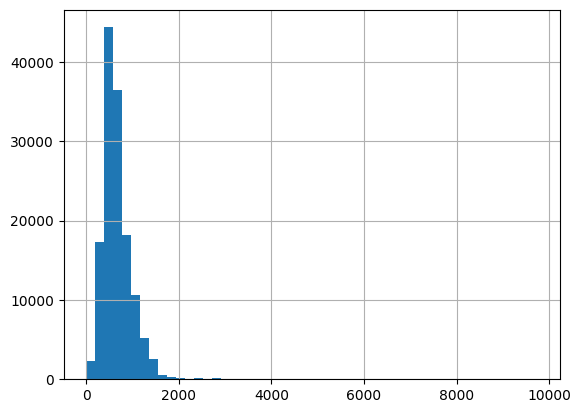

In [1749]:
sales_df['revenue'].hist(bins=50)

Revenue and quantity distributions were inspected to understand typical transaction sizes and identify potential outliers.


<Axes: xlabel='date'>

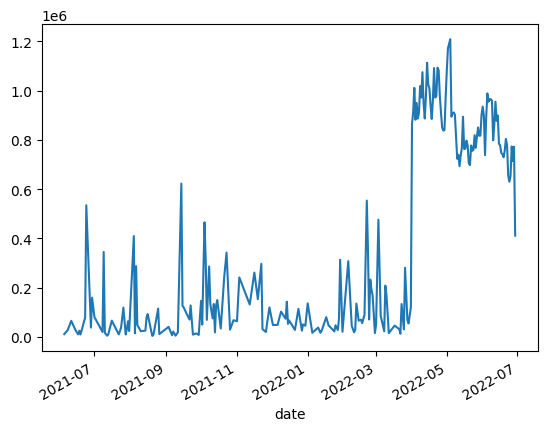

In [1750]:
sales_df.groupby('date')['revenue'].sum().plot()

<Axes: xlabel='month'>

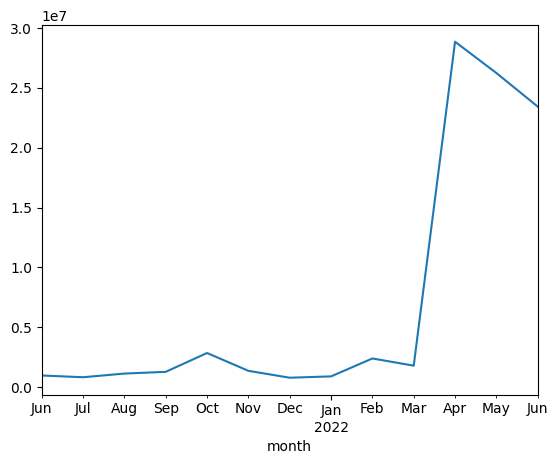

In [1751]:
sales_df['month'] = sales_df['date'].dt.to_period('M')
sales_df.groupby('month')['revenue'].sum().plot()

Time-based aggregation reveals overall sales trends and highlights periods of increased or decreased activity.


In [1752]:
sales_df.groupby('region').agg(
    total_revenue=('revenue', 'sum'),
    total_units=('units_sold', 'sum')
)

,total_revenue,total_units
region,,
Domestic,78592678.3,121180.0
International,14349670.0,22394.0


Sales performance was compared across regions to assess differences in revenue contribution and sales volume.


In [1753]:
category_perf = sales_df.groupby('category').agg(
    total_revenue=('revenue', 'sum'),
    total_units=('units_sold', 'sum')
).sort_values(by='total_revenue', ascending=False)

category_perf.head(10)


,total_revenue,total_units
category,,
Set,39204124.03,47042.0
Kurta,21299546.70,46717.0
Western Dress,11216072.69,14704.0
Top,5347792.30,10165.0
Ethnic Dress,791217.66,1093.0
Blouse,458408.18,881.0
Bottom,150667.98,420.0
Saree,123933.76,155.0
Dupatta,915.00,3.0


<Axes: xlabel='category'>

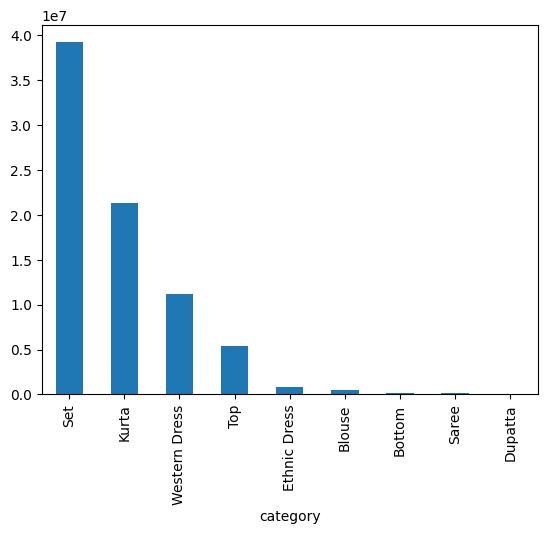

In [1754]:
category_perf.head(10)['total_revenue'].plot.bar()


Product categories were ranked by total revenue and units sold to identify primary revenue drivers.


In [1755]:
sales_df.groupby('sku').agg(
    total_units=('units_sold', 'sum'),
    total_revenue=('revenue', 'sum')
).sort_values(by='total_units', ascending=False).head(10)

,total_units,total_revenue
sku,,
JNE3797-KR-L,722.0,524581.77
JNE3797-KR-M,622.0,455265.16
JNE3797-KR-S,553.0,407302.57
JNE3405-KR-L,516.0,206852.29
J0230-SKD-M,487.0,549334.20
JNE3797-KR-XL,448.0,334007.24
J0230-SKD-S,437.0,492902.14
JNE3405-KR-S,430.0,175945.87
JNE3405-KR-M,409.0,160273.29


<Axes: xlabel='total_units', ylabel='total_revenue'>

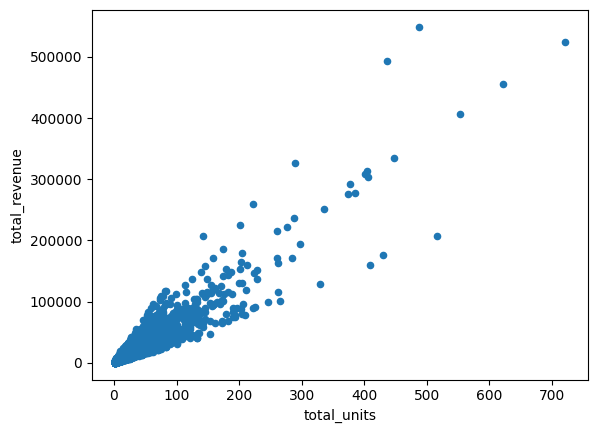

In [1756]:
sales_df.groupby('sku').agg(
    total_units=('units_sold', 'sum'),
    total_revenue=('revenue', 'sum')
).plot.scatter(x='total_units', y='total_revenue')

SKU-level analysis highlights differences between high-volume and high-value products.


In [1757]:
sales_df.shape

(138398, 31)

In [1758]:
sales_df.dtypes

order_id                      object
date                  datetime64[ns]
status                        object
fulfilment                    object
sales_channel                 object
ship_service_level            object
style                         object
sku                           object
category                      object
size                          object
asin                          object
courier_status                object
units_sold                   float64
currency                      object
amount                       float64
ship_city                     object
ship_state                    object
ship_postal_code              object
ship_country                  object
promotion_ids                 object
b2b                           object
fulfilled_by                  object
revenue                      float64
platform                      object
region                        object
months                        object
customer                      object
p

In [1759]:
sales_df.head()

,order_id,date,status,fulfilment,sales_channel,ship_service_level,style,sku,category,size,asin,courier_status,units_sold,currency,amount,ship_city,ship_state,ship_postal_code,ship_country,promotion_ids,b2b,fulfilled_by,revenue,platform,region,months,customer,pcs,rate,gross_amt,month
0,405-8078784-5731545,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,S,B09KXVBD7Z,Unknown,1.0,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,Unknown,False,Easy Ship,647.62,Amazon,Domestic,NaN,NaN,NaN,NaN,NaN,2022-04
1,171-9198151-1101146,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,Kurta,3XL,B09K3WFS32,Shipped,1.0,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,406.00,Amazon,Domestic,NaN,NaN,NaN,NaN,NaN,2022-04
2,404-0687676-7273146,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,Kurta,XL,B07WV4JV4D,Shipped,1.0,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,329.00,Amazon,Domestic,NaN,NaN,NaN,NaN,NaN,2022-04
3,403-9615377-8133951,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,L,B099NRCT7B,Unknown,1.0,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,Unknown,False,Easy Ship,753.33,Amazon,Domestic,NaN,NaN,NaN,NaN,NaN,2022-04
4,407-1069790-7240320,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,B098714BZP,Shipped,1.0,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,Unknown,False,NaN,574.00,Amazon,Domestic,NaN,NaN,NaN,NaN,NaN,2022-04


In [1760]:
sales_df.isna().sum()

order_id               17218
date                       0
status                 17218
fulfilment             17218
sales_channel          17218
ship_service_level     17218
style                      0
sku                        0
category               17218
size                       0
asin                   17218
courier_status         17218
units_sold                 0
currency               17218
amount                 17218
ship_city              17218
ship_state             17218
ship_postal_code       17218
ship_country           17218
promotion_ids          17218
b2b                    17218
fulfilled_by          100857
revenue                    0
platform                   0
region                     0
months                121180
customer              121180
pcs                   121180
rate                  121180
gross_amt             121180
month                      0
dtype: int64

In [1761]:
analysis_cols = [
    'date',
    'sku',
    'category',
    'revenue',
    'units_sold',
    'platform',
    'region'
]

sales_analysis_df = sales_df[analysis_cols]

In [1762]:
sales_analysis_df.isna().sum()

date              0
sku               0
category      17218
revenue           0
units_sold        0
platform          0
region            0
dtype: int64

Product category information is available for domestic Amazon sales only. International transactions were retained without category labels.


In [1763]:
sales_analysis_df['date'].dtype

dtype('<M8[ns]')

In [1764]:
daily_revenue = (
    sales_analysis_df
    .groupby('date')['revenue']
    .sum()
)

daily_revenue.head()

date
2021-06-05    11685.0
2021-06-08    27989.0
2021-06-11    65504.0
2021-06-15    25195.0
2021-06-17    10547.0
Name: revenue, dtype: float64

<Axes: title={'center': 'Daily Revenue Over Time'}, xlabel='date'>

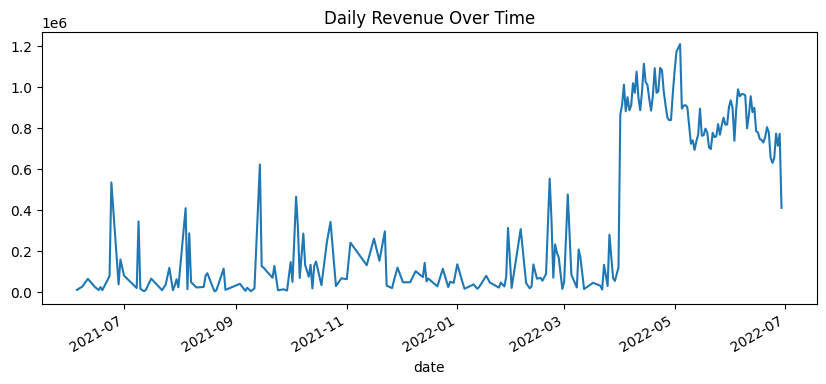

In [1765]:
daily_revenue.plot(
    title='Daily Revenue Over Time',
    figsize=(10, 4)
)

Daily revenue was aggregated to observe overall sales activity and identify temporal patterns.


In [1766]:
sales_analysis_df['month'] = sales_analysis_df['date'].dt.to_period('M')

monthly_revenue = (
    sales_analysis_df
    .groupby('month')['revenue']
    .sum()
)

monthly_revenue

/var/folders/sg/b02gb65s12gdhpzj3hds2n1m0000gn/T/ipykernel_15232/1187615396.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sales_analysis_df['month'] = sales_analysis_df['date'].dt.to_period('M')


month
2021-06      988233.00
2021-07      843551.00
2021-08     1148793.00
2021-09     1294339.00
2021-10     2865134.00
2021-11     1378104.00
2021-12      802418.00
2022-01      913688.00
2022-02     2408936.00
2022-03     1808157.85
2022-04    28838708.32
2022-05    26226476.75
2022-06    23425809.38
Freq: M, Name: revenue, dtype: float64

<Axes: title={'center': 'Monthly Revenue Over Time'}, xlabel='month'>

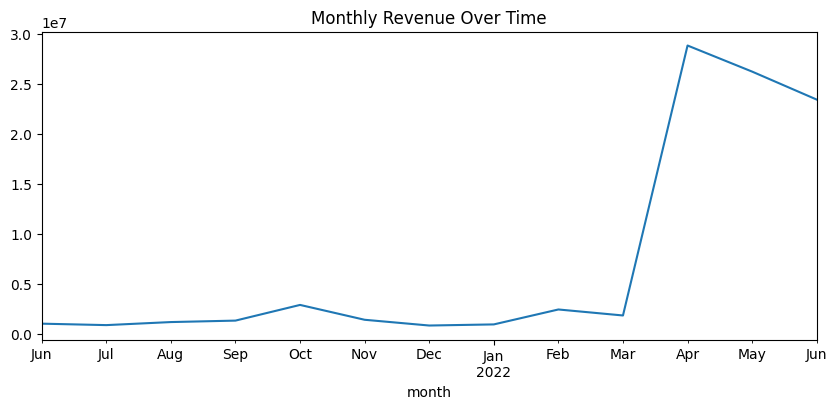

In [1767]:
monthly_revenue.plot(
    title='Monthly Revenue Over Time',
    figsize=(10, 4)
)

Monthly aggregation smooths daily fluctuations and highlights broader revenue trends over time.


<Axes: title={'center': 'Monthly Units Sold Over Time'}, xlabel='month'>

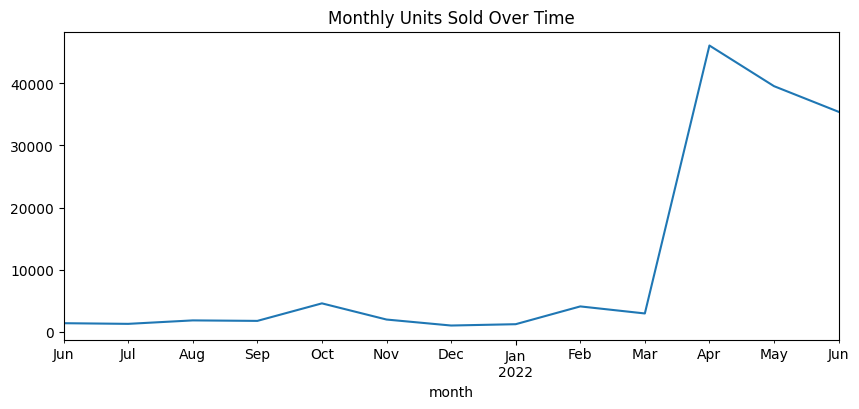

In [1768]:
monthly_units = (
    sales_analysis_df
    .groupby('month')['units_sold']
    .sum()
)

monthly_units.plot(
    title='Monthly Units Sold Over Time',
    figsize=(10, 4)
)

Units sold were aggregated monthly to compare volume trends alongside revenue patterns.


In [1769]:
sales_analysis_df['category'].value_counts(dropna=False).head()

category
Set              47042
Kurta            46717
NaN              17218
Western Dress    14704
Top              10165
Name: count, dtype: int64

In [1770]:
category_perf = (
    sales_analysis_df
    .dropna(subset=['category'])   # only rows where category exists
    .groupby('category')
    .agg(
        total_revenue=('revenue', 'sum'),
        total_units=('units_sold', 'sum')
    )
    .sort_values(by='total_revenue', ascending=False)
)

category_perf.head(10)

,total_revenue,total_units
category,,
Set,39204124.03,47042.0
Kurta,21299546.70,46717.0
Western Dress,11216072.69,14704.0
Top,5347792.30,10165.0
Ethnic Dress,791217.66,1093.0
Blouse,458408.18,881.0
Bottom,150667.98,420.0
Saree,123933.76,155.0
Dupatta,915.00,3.0


<Axes: title={'center': 'Top 10 Categories by Revenue'}, xlabel='category'>

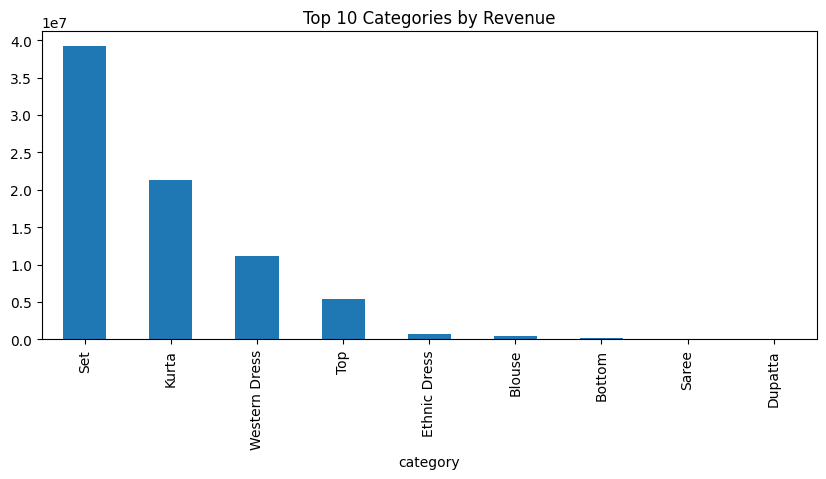

In [1771]:
category_perf.head(10)['total_revenue'].plot.bar(
    title='Top 10 Categories by Revenue',
    figsize=(10, 4)
)

<Axes: title={'center': 'Top 10 Categories by Units Sold'}, xlabel='category'>

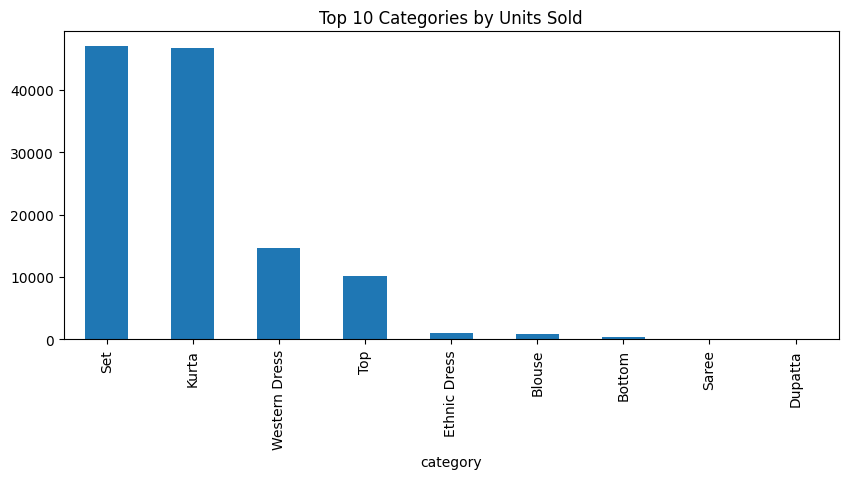

In [1772]:
category_perf.head(10)['total_units'].plot.bar(
    title='Top 10 Categories by Units Sold',
    figsize=(10, 4)
)

Product categories were aggregated to evaluate their contribution to total revenue and sales volume. Analysis focuses on categories with available classification data.


In [1773]:
region_perf = (
    sales_analysis_df
    .groupby('region')
    .agg(
        total_revenue=('revenue', 'sum'),
        total_units=('units_sold', 'sum')
    )
)

region_perf

,total_revenue,total_units
region,,
Domestic,78592678.3,121180.0
International,14349670.0,22394.0


<Axes: title={'center': 'Revenue by Region'}, xlabel='region'>

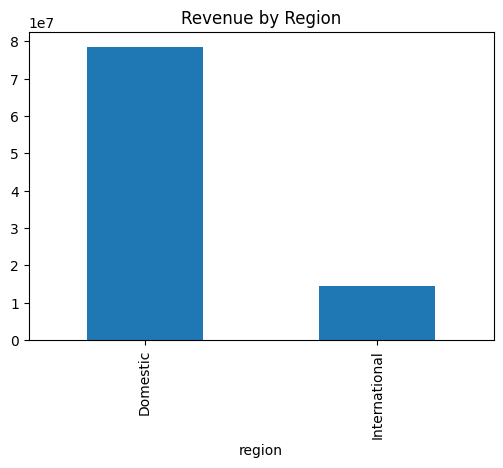

In [1774]:
region_perf['total_revenue'].plot.bar(
    title='Revenue by Region',
    figsize=(6, 4)
)

<Axes: title={'center': 'Units Sold by Region'}, xlabel='region'>

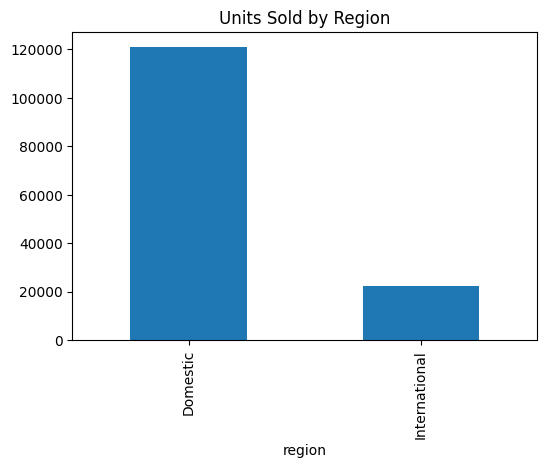

In [1775]:
region_perf['total_units'].plot.bar(
    title='Units Sold by Region',
    figsize=(6, 4)
)

Sales performance was compared between domestic and international transactions by aggregating total revenue and units sold for each region.


In [1776]:
sku_perf = (
    sales_analysis_df
    .groupby('sku')
    .agg(
        total_units=('units_sold', 'sum'),
        total_revenue=('revenue', 'sum')
    )
)

In [1777]:
sku_perf.head()

,total_units,total_revenue
sku,,
AN201-RED-M,2.0,458.0
AN201-RED-XL,2.0,602.0
AN201-RED-XXL,1.0,229.0
AN202-ORANGE-L,1.0,281.0
AN202-ORANGE-M,3.0,811.0


In [1778]:
top_volume_skus = (
    sku_perf
    .sort_values(by='total_units', ascending=False)
    .head(10)
)

top_volume_skus

,total_units,total_revenue
sku,,
JNE3797-KR-L,722.0,524581.77
JNE3797-KR-M,622.0,455265.16
JNE3797-KR-S,553.0,407302.57
JNE3405-KR-L,516.0,206852.29
J0230-SKD-M,487.0,549334.20
JNE3797-KR-XL,448.0,334007.24
J0230-SKD-S,437.0,492902.14
JNE3405-KR-S,430.0,175945.87
JNE3405-KR-M,409.0,160273.29


In [1779]:
top_value_skus = (
    sku_perf
    .sort_values(by='total_revenue', ascending=False)
    .head(10)
)

top_value_skus

,total_units,total_revenue
sku,,
J0230-SKD-M,487.0,549334.20
JNE3797-KR-L,722.0,524581.77
J0230-SKD-S,437.0,492902.14
JNE3797-KR-M,622.0,455265.16
JNE3797-KR-S,553.0,407302.57
JNE3797-KR-XL,448.0,334007.24
J0230-SKD-L,290.0,327050.95
SET268-KR-NP-XL,404.0,313307.96
SET268-KR-NP-L,402.0,309334.00


<Axes: title={'center': 'SKU Volume vs Revenue'}, xlabel='total_units', ylabel='total_revenue'>

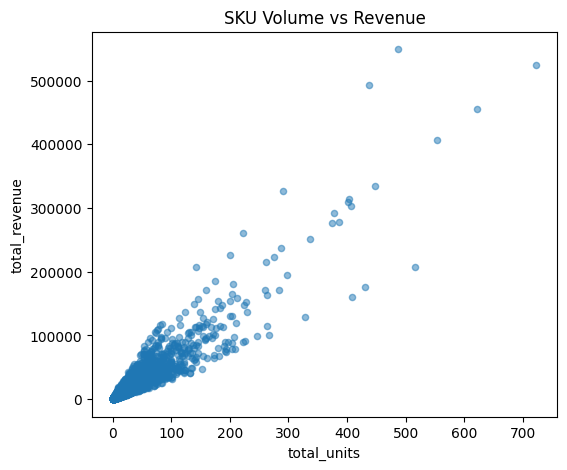

In [1780]:
sku_perf.plot.scatter(
    x='total_units',
    y='total_revenue',
    figsize=(6, 5),
    alpha=0.5,
    title='SKU Volume vs Revenue'
)

SKU-level aggregation highlights differences between high-volume products and high-revenue products. The analysis shows that products contributing most to unit sales are not always those generating the highest revenue.

In [1781]:
amazon_ds.to_csv("amazon_sales_clean.csv", index=False)
international_sales_report_ds.to_csv(
    "international_sales_clean.csv",
    index=False
)

In [1782]:
import os
os.listdir()

['.DS_Store',
 'amazon_ecommerce_sales_analysis.ipynb',
 'international_sales_clean.csv',
 'E-commerce_sales_PP.ipynb',
 'amazon_sales_clean.csv']